In [37]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression, RidgeClassifier, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error 

In [3]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [11]:
X = data.data
y = data.target

In [15]:
# train-test plit the data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)

## Simple Linear Regression 

In [19]:
#Make an object of Linear Regression
L = LinearRegression()

In [21]:
# fit the model on training data
L.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
# Predict on test data 
y_pred = L.predict(X_test)

In [25]:
# Print values of Coef and intercept 
print(L.coef_)
print(L.intercept_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
151.34560453985995


In [31]:
# Find R2_score and RMSE
L_R2_score = r2_score(y_test, y_pred)
L_RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression r2_score", L_R2_score)
print("Linear Regression RMSE", L_RMSE)

Linear Regression r2_score 0.45260276297191926
Linear Regression RMSE 53.853445836765935


## Ridge Regression 

In [125]:
# Make an  object of Redge 
R = Ridge(alpha = 0.0001)

In [127]:
# fit the model on training data
R.fit(X_train, y_train)

,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [129]:
# Predict on test data 
y_pred1 = R.predict(X_test)

In [131]:
# Print values of Coef and intercept 
print(R.coef_)
print(R.intercept_)

[  37.96896668 -241.90045995  542.59350355  347.60408828 -919.86392412
  508.99591979  158.21377613  273.68991875  731.71430503   48.78691955]
151.34517874825505


In [133]:
# Find R2_score and RMSE
R_R2_score = r2_score(y_test, y_pred1)
R_RMSE = np.sqrt(mean_squared_error(y_test, y_pred1))

print("Ridge Regularization r2_score", R_R2_score)
print("Ridge Regularization RMSE", R_RMSE)

Ridge Regularization r2_score 0.4526998154220113
Ridge Regularization RMSE 53.84867157029344


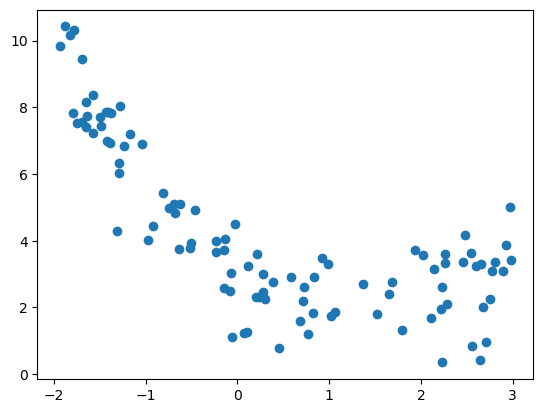

In [123]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

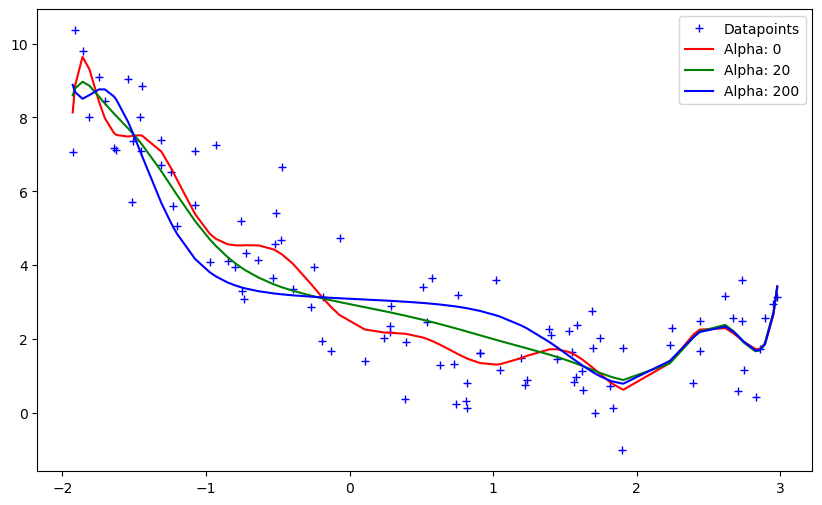

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()